<a href="https://colab.research.google.com/github/Kirans1ngh/Machine-Learning-practice/blob/main/Classification/HeartDisease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


--- Bayesian ---
Accuracy: 0.9079
[[54  1]
 [ 6 15]]

--- Decision Tree ---
Accuracy: 0.8289
[[53  2]
 [11 10]]

--- Neural Network ---
Accuracy: 0.8816
[[53  2]
 [ 7 14]]


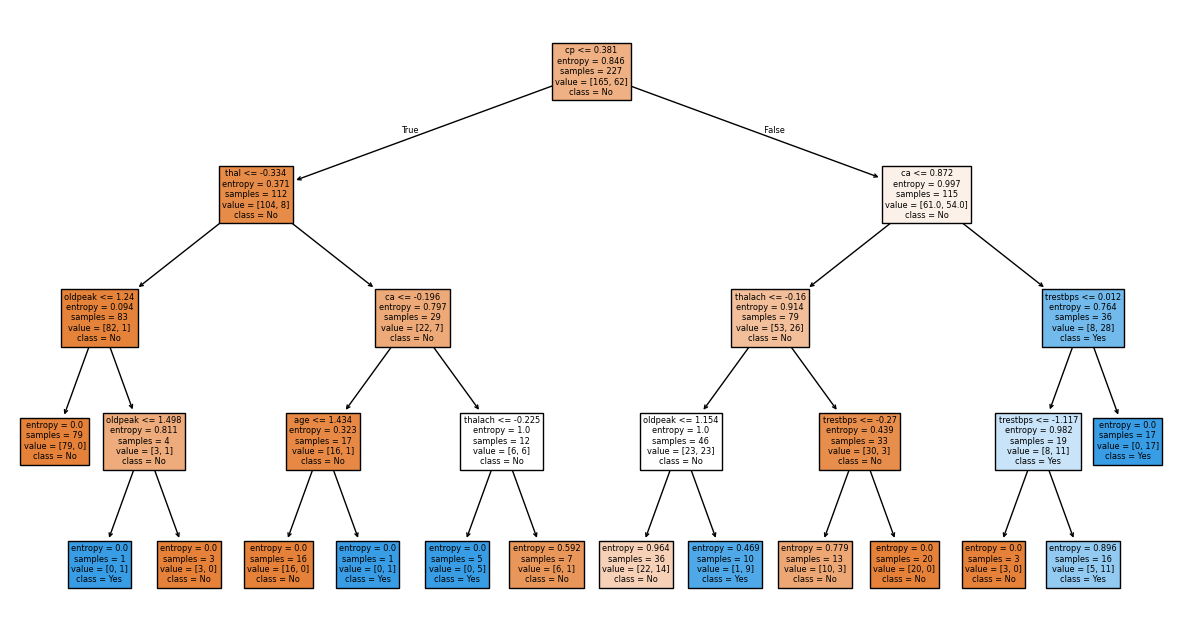

Bayesian Prediction: No Disease
Decision Tree Prediction: No Disease
Neural Network Prediction: No Disease


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Data Loading & Preprocessing
url = "https://storage.googleapis.com/download.tensorflow.org/data/heart.csv"
df = pd.read_csv(url)
df["thal"] = df["thal"].map({"normal": 0, "fixed": 1, "reversible": 2})

X = df.drop(columns=["target"])
y = df["target"]

imputer = SimpleImputer(strategy="most_frequent")
X_imp = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42, stratify=y)

# Model Definitions
models = {
    "Bayesian": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000, random_state=42)
}

# Training and Evaluation
for name, clf in models.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    print(f"\n--- {name} ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(confusion_matrix(y_test, y_pred))

# Tree Visualization
plt.figure(figsize=(15, 8))
plot_tree(models["Decision Tree"], feature_names=X.columns, class_names=["No", "Yes"], filled=True)
plt.show()

# Sample Prediction
sample = [57, 1, 2, 140, 241, 0, 1, 123, 1, 0.2, 1, 0, "reversible"]
sample[12] = {"normal": 0, "fixed": 1, "reversible": 2}[sample[12]]
sample_scaled = scaler.transform([sample])

for name, clf in models.items():
    res = clf.predict(sample_scaled)[0]
    print(f"{name} Prediction: {'Disease' if res == 1 else 'No Disease'}")